# Frontal-Midline Theta (FM-theta) Step-by-Step Test

This notebook tests the FM-theta pipeline in `ppg_eeg.eeg` on one existing EEG file in this repo.

Functions tested:
- `preprocess_eeg`
- `_theta_power_per_channel` (internal helper)
- `fm_theta` (linear and log-transformed)
- `frontal_midline_theta` (convenience wrapper)
- `plot_fm_theta`

FM-theta here is computed as theta-band power over frontal-midline channels, averaged across channels, with optional natural-log transform.


In [14]:
%matplotlib inline

from pathlib import Path
import sys
import importlib
import numpy as np
import mne
import matplotlib.pyplot as plt

# Make imports robust regardless of notebook working directory.
repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ppg_eeg").is_dir():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError("Could not locate repo root containing 'ppg_eeg' directory.")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo root:", repo_root)

# Force-refresh module in case the kernel cached an older version.
import ppg_eeg.eeg as eeg_mod
eeg_mod = importlib.reload(eeg_mod)
print("Loaded eeg module from:", eeg_mod.__file__)

if not hasattr(eeg_mod, "plot_fm_theta"):
    raise RuntimeError(
        "Current kernel loaded a ppg_eeg.eeg without plot_fm_theta. "
        "Restart kernel and re-run from the first cell."
    )

FRONTAL_MIDLINE_CHANNELS_DEFAULT = eeg_mod.FRONTAL_MIDLINE_CHANNELS_DEFAULT
preprocess_eeg = eeg_mod.preprocess_eeg
_theta_power_per_channel = eeg_mod._theta_power_per_channel
fm_theta = eeg_mod.fm_theta
frontal_midline_theta = eeg_mod.frontal_midline_theta
plot_fm_theta = eeg_mod.plot_fm_theta


Using repo root: /Users/sarabonyadian/Documents/HIIT/ppg-eeg
Loaded eeg module from: /Users/sarabonyadian/Documents/HIIT/ppg-eeg/ppg_eeg/eeg.py


In [15]:
# Choose one EEG file from a non-HIIT dataset (prefer ds006848)
raw_data_dir = repo_root / "data" / "raw"
preferred_dataset_dir = raw_data_dir / "ds006848"

if preferred_dataset_dir.is_dir():
    candidate_files = sorted(preferred_dataset_dir.rglob("*.vhdr"))
    dataset_used = preferred_dataset_dir.name
else:
    # Fallback: any non-HIIT folder under data/raw
    candidate_files = []
    dataset_used = None
    for d in sorted(raw_data_dir.iterdir()):
        if d.is_dir() and d.name.lower() != "hiit":
            files = sorted(d.rglob("*.vhdr"))
            if files:
                candidate_files = files
                dataset_used = d.name
                break

if not candidate_files:
    raise FileNotFoundError(
        f"No BrainVision .vhdr file found in non-HIIT datasets under {raw_data_dir}"
    )

# Prefer rest recordings in ds006848, otherwise first file.
rest_files = [p for p in candidate_files if "task-rest" in p.name]
eeg_vhdr_path = rest_files[0] if rest_files else candidate_files[0]

print("Dataset used:", dataset_used)
print("Selected EEG file:", eeg_vhdr_path)


Dataset used: ds006848
Selected EEG file: /Users/sarabonyadian/Documents/HIIT/ppg-eeg/data/raw/ds006848/sub-001/eeg/sub-001_task-rest_eeg.vhdr


In [16]:
# Load EEG and keep EEG channels only
raw = mne.io.read_raw_brainvision(eeg_vhdr_path, preload=True, verbose="ERROR")
raw.pick_types(eeg=True)

print(raw)
print("Sampling frequency:", raw.info["sfreq"])
print("Number of EEG channels:", len(raw.ch_names))


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<RawBrainVision | sub-001_task-rest_eeg.eeg, 64 x 732280 (732.3 s), ~357.6 MiB, data loaded>
Sampling frequency: 1000.0
Number of EEG channels: 64


In [17]:
# Step 0: preprocess (band-pass, drop bad channels, common-average reference)
pre = preprocess_eeg(raw)
raw_pp = pre.raw

print("Bad channels dropped:", pre.bad_channels)
print("Remaining channels:", len(raw_pp.ch_names))


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Bad channels dropped: ['ECG']
Remaining channels: 63


In [18]:
# Inspect which default FM-theta channels are usable in this file
available = [ch for ch in FRONTAL_MIDLINE_CHANNELS_DEFAULT if ch in raw_pp.ch_names]
missing = [ch for ch in FRONTAL_MIDLINE_CHANNELS_DEFAULT if ch not in raw_pp.ch_names]

print("Default frontal-midline channels:", FRONTAL_MIDLINE_CHANNELS_DEFAULT)
print("Available channels in this file:", available)
print("Missing channels in this file:", missing)


Default frontal-midline channels: ['Fz', 'FCz', 'Cz']
Available channels in this file: ['Fz', 'Cz']
Missing channels in this file: ['FCz']


In [19]:
# Step 1: internal helper _theta_power_per_channel
theta_per_ch = _theta_power_per_channel(
    raw_pp,
    FRONTAL_MIDLINE_CHANNELS_DEFAULT,
    theta_band=(4.0, 7.0),
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("Per-channel theta power (uV^2):")
for ch in FRONTAL_MIDLINE_CHANNELS_DEFAULT:
    val = theta_per_ch.get(ch)
    if val is None or not np.isfinite(val):
        print(f"  {ch}: NaN")
    else:
        print(f"  {ch}: {val:.6f}")


Per-channel theta power (uV^2):
  Fz: 7.543342
  FCz: NaN
  Cz: 3.596977


In [20]:
# Step 2: fm_theta without log-transform (linear mean theta power)
res_linear = fm_theta(
    raw_pp,
    channels=FRONTAL_MIDLINE_CHANNELS_DEFAULT,
    theta_band=(4.0, 7.0),
    log_transform=False,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("theta_band_used:", res_linear.theta_band_used)
print("per_channel_power:")
for ch, val in res_linear.per_channel_power.items():
    print(f"  {ch}: {val:.6f}" if np.isfinite(val) else f"  {ch}: NaN")
print("mean_theta_power (uV^2):", res_linear.mean_theta_power)
print("fm_theta (linear):", res_linear.fm_theta)
print("missing_channels:", res_linear.missing_channels)


theta_band_used: (4.0, 7.0)
per_channel_power:
  Fz: 7.543342
  FCz: NaN
  Cz: 3.596977
mean_theta_power (uV^2): 5.570159326905475
fm_theta (linear): 5.570159326905475
missing_channels: ['FCz']


In [21]:
# Step 3: fm_theta with log-transform (recommended scalar)
res_log = fm_theta(
    raw_pp,
    channels=FRONTAL_MIDLINE_CHANNELS_DEFAULT,
    theta_band=(4.0, 7.0),
    log_transform=True,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("mean_theta_power (uV^2):", res_log.mean_theta_power)
print("fm_theta (log):", res_log.fm_theta)
if np.isfinite(res_log.mean_theta_power) and res_log.mean_theta_power > 0:
    print("Manual ln(mean_theta_power):", np.log(res_log.mean_theta_power))


mean_theta_power (uV^2): 5.570159326905475
fm_theta (log): 1.7174236580014526
Manual ln(mean_theta_power): 1.7174236580014526


In [22]:
# Step 4: convenience wrapper should match fm_theta(..., log_transform=True).fm_theta
fm_wrapper = frontal_midline_theta(
    raw_pp,
    channels=FRONTAL_MIDLINE_CHANNELS_DEFAULT,
    theta_band=(4.0, 7.0),
    log_transform=True,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("frontal_midline_theta:", fm_wrapper)
print("fm_theta(...).fm_theta:", res_log.fm_theta)

if np.isfinite(fm_wrapper) and np.isfinite(res_log.fm_theta):
    print("Abs difference:", abs(fm_wrapper - res_log.fm_theta))
    assert np.isclose(fm_wrapper, res_log.fm_theta, atol=1e-12)
    print("OK: wrapper matches fm_theta output.")
else:
    print("At least one value is NaN; equality check skipped.")


frontal_midline_theta: 1.7174236580014526
fm_theta(...).fm_theta: 1.7174236580014526
Abs difference: 0.0
OK: wrapper matches fm_theta output.


plot_fm_theta -> fm_theta: 1.7174236580014526
plot_fm_theta -> mean_theta_power (uV^2): 5.570159326905475
plot_fm_theta -> missing_channels: ['FCz']


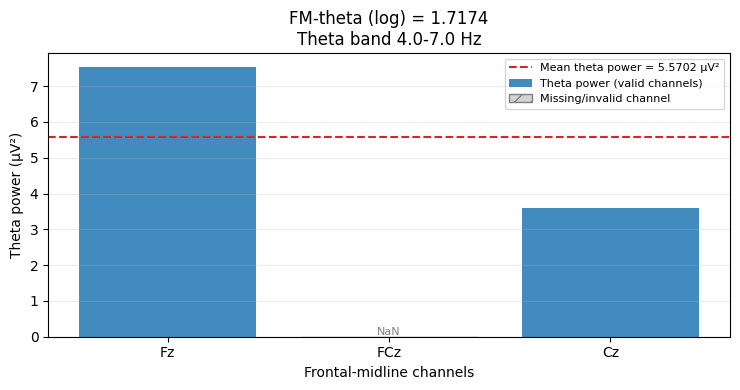

In [23]:
# Step 5: plot_fm_theta visualization
plot_res = plot_fm_theta(
    raw_pp,
    channels=FRONTAL_MIDLINE_CHANNELS_DEFAULT,
    theta_band=(4.0, 7.0),
    log_transform=True,
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
)

print("plot_fm_theta -> fm_theta:", plot_res.result.fm_theta)
print("plot_fm_theta -> mean_theta_power (uV^2):", plot_res.result.mean_theta_power)
print("plot_fm_theta -> missing_channels:", plot_res.result.missing_channels)

plt.show()